
# Finite-sample bias in ordinal complexity–entropy planes
## Full reproducibility notebook

This notebook consolidates the computational pipeline for the manuscript:

**A. M. S. Borin Jr., R. H. Rosa, R. R. Ferreira**  
*Finite-sample bias in ordinal complexity–entropy planes: exact identities under overlapping patterns*

### What `Run All` does
1. Recomputes the exact IID overlap probabilities \(g(h)\) for \(m=3,4,5\).
2. Recomputes exact ordinal probabilities for the logistic map and AR(1) reference processes.
3. Runs the manuscript Monte Carlo bias/RMSE experiments.
4. Runs the quantization/tie experiment.
5. Runs the single-series circular block-bootstrap coverage experiment.
6. Runs the calibrated IID-white-noise rank test (size and power).
7. Regenerates **Figures 1–5 in English**.
8. Executes numerical checks against key values reported in the manuscript.

No empirical dataset is required. All series are generated in the notebook.

> **Important:** `FULL_REPRODUCTION = True` uses the manuscript-scale settings (5000 Monte Carlo replications, 500 outer bootstrap replications with 499 resamples, and 9999 null simulations). This is computationally intensive. Set it to `False` only for a quick code check; quick-mode results should not be used to verify the numerical values in the paper.


In [1]:

from pathlib import Path
from functools import lru_cache
from fractions import Fraction
from itertools import permutations
from math import factorial, log, ceil
import time, platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import xlogy, digamma
from scipy.signal import lfilter
from scipy.stats import norm

FULL_REPRODUCTION = True

if FULL_REPRODUCTION:
    R_BIAS = 5000
    R_GAP = 5000
    R_TIES = 3000
    R_BOOT = 500
    B_BOOT = 499
    R_TEST = 5000
    B_NULL = 9999
else:
    R_BIAS = 300
    R_GAP = 300
    R_TIES = 300
    R_BOOT = 50
    B_BOOT = 99
    R_TEST = 300
    B_NULL = 999

Ns = [50, 100, 200, 500, 1000, 2000]
SEED = 20260908
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("FULL_REPRODUCTION =", FULL_REPRODUCTION)
print(dict(R_BIAS=R_BIAS, R_BOOT=R_BOOT, B_BOOT=B_BOOT, R_TEST=R_TEST, B_NULL=B_NULL))


Python: 3.11.14
NumPy: 2.2.6
FULL_REPRODUCTION = True
{'R_BIAS': 5000, 'R_BOOT': 500, 'B_BOOT': 499, 'R_TEST': 5000, 'B_NULL': 9999}


## 1. Core ordinal-pattern estimators and exact reference calculations

In [2]:
"""Ordinal estimators. No clipping, hidden support filling, or oracle standard errors."""
from functools import lru_cache
from fractions import Fraction
from itertools import permutations
from math import factorial, log, ceil
import numpy as np
from scipy.special import xlogy, digamma

@lru_cache(None)
def codebook(m):
    return np.sort(np.array(list(permutations(range(m))),dtype=np.int64) @ (m**np.arange(m)))

def symbols(x,m,tau=1,stride=1):
    """Increasing-value index permutation; strict no-ties policy; last axis is time."""
    x=np.asarray(x,float)
    if m<2 or tau<1 or stride<1 or not np.isfinite(x).all(): raise ValueError('invalid input')
    span=(m-1)*tau+1
    if x.shape[-1]<span: raise ValueError('series shorter than embedding')
    e=np.lib.stride_tricks.sliding_window_view(x,span,axis=-1)[...,::stride,::tau]
    rank=np.argsort(e,axis=-1,kind='stable')
    ordered=np.take_along_axis(e,rank,axis=-1)
    if np.any(np.diff(ordered,axis=-1)==0): raise ValueError('ties within ordinal window')
    return np.searchsorted(codebook(m),rank @ (m**np.arange(m)))

def histograms(s,M):
    s=np.asarray(s,dtype=np.int64)
    if s.ndim==1: return np.bincount(s,minlength=M)
    if s.ndim!=2: raise ValueError('one or two dimensional symbol array required')
    return np.bincount((s+M*np.arange(len(s))[:,None]).ravel(),minlength=len(s)*M).reshape(-1,M)

def q0(M):
    q=np.full(M,1/(2*M));q[0]=(1+1/M)/2
    return 1/(-xlogy(q,q).sum()-.5*log(M))

def functionals(p):
    """Return H,D,C_LMC,C_JS along final axis; accepts zero probabilities."""
    p=np.asarray(p,float); M=p.shape[-1]
    S=-xlogy(p,p).sum(axis=-1); H=S/log(M)
    D=((p-1/M)**2).sum(axis=-1)
    q=(p+1/M)/2
    J=-xlogy(q,q).sum(axis=-1)-.5*S-.5*log(M)
    return np.stack([H,D,H*D,q0(M)*H*J],axis=-1)

def u_estimate(c):
    c=np.asarray(c);n=c.sum(axis=-1)
    if np.any(n<2): raise ValueError('at least two observations required')
    return (c*(c-1)).sum(axis=-1)/(n*(n-1))-1/c.shape[-1]

def gap_estimate(s,M,w):
    s=np.asarray(s);n=s.shape[-1]
    if w<0 or w>n-2: raise ValueError('no eligible pairs')
    c=histograms(s,M)
    collisions=(c*(c-1)).sum(axis=-1)/2
    for h in range(1,w+1): collisions-=np.sum(s[...,:-h]==s[...,h:],axis=-1)
    return collisions/((n-w-1)*(n-w)/2)-1/M

@lru_cache(None)
def iid_collision_probabilities(m):
    if not 2<=m<=5: raise ValueError('exact enumeration implemented for 2<=m<=5')
    ans=[]
    for h in range(1,m):
        a=np.array(list(permutations(range(m+h))),dtype=np.int8)
        same=np.all(np.argsort(a[:,:m],axis=1)==np.argsort(a[:,h:h+m],axis=1),axis=1).sum()
        ans.append(Fraction(int(same),factorial(m+h)))
    return ans

def iid_biases(m,n):
    if n<2: raise ValueError('n must exceed one')
    M=factorial(m)
    s=sum((n-h)*(a-Fraction(1,M)) for h,a in enumerate(iid_collision_probabilities(m),1) if h<n)
    return {'plugin':(1-1/M)/n+2*float(s)/n**2,'U':2*float(s)/(n*(n-1))}

@lru_cache(None)
def logistic_rational(m):
    """Exact invariant ordinal probabilities, including exact midpoint ranking."""
    bounds={Fraction(0),Fraction(1)}
    for i in range(m):
        for j in range(i+1,m):
            for d in [2**j-2**i,2**j+2**i]:
                bounds.update(Fraction(k,d) for k in range(d+1))
    bounds=sorted(bounds); probs=[Fraction(0) for _ in range(factorial(m))]
    for lo,hi in zip(bounds[:-1],bounds[1:]):
        t=(lo+hi)/2
        a=[(2**k*t)%1 for k in range(m)]
        folded=[min(v,1-v) for v in a] # sin²(pi z) strictly increases for 0<=z<=1/2
        assert len(set(folded))==m
        rank=sorted(range(m),key=lambda k:folded[k])
        code=sum(v*m**k for k,v in enumerate(rank))
        probs[int(np.searchsorted(codebook(m),code))]+=hi-lo
    assert sum(probs)==1
    return tuple(probs)

def logistic_probabilities(m):
    return np.array([float(v) for v in logistic_rational(m)])

def ar_probabilities(m,phi,tau=1):
    """Gaussian orthant formula in dimensions 2 and 3; exact up to floating arithmetic."""
    if m not in (3,4) or abs(phi)>=1 or tau<1: raise ValueError('m=3,4 and stationary AR required')
    R=phi**(tau*np.abs(np.arange(m)[:,None]-np.arange(m)))
    p=np.empty(factorial(m))
    for rank in permutations(range(m)):
        B=np.zeros((m-1,m))
        for k in range(m-1): B[k,rank[k+1]]=1;B[k,rank[k]]=-1
        V=B@R@B.T; cor=V/np.sqrt(np.outer(np.diag(V),np.diag(V)))
        if m==3: val=.25+np.arcsin(cor[0,1])/(2*np.pi)
        else: val=.125+(np.arcsin(cor[0,1])+np.arcsin(cor[0,2])+np.arcsin(cor[1,2]))/(4*np.pi)
        code=sum(v*m**k for k,v in enumerate(rank))
        p[int(np.searchsorted(codebook(m),code))]=val
    return p

def hessians(p):
    p=np.asarray(p,float);M=len(p)
    if np.any(p<=0): raise ValueError('fixed positive support required')
    H,D,_,_=functionals(p);q=(p+1/M)/2
    S=-xlogy(p,p).sum();J=-xlogy(q,q).sum()-.5*S-.5*log(M)
    a=-(np.log(p)+1)/log(M); b=.5*np.log(p/q); d=2*(p-1/M)
    HH=np.diag(-1/(p*log(M))); DD=2*np.eye(M); JJ=np.diag(.5/p-.25/q)
    return np.array([HH,DD,D*HH+H*DD+np.outer(a,d)+np.outer(d,a),q0(M)*(J*HH+H*JJ+np.outer(a,b)+np.outer(b,a))])

def estimates(s,M,w):
    c=histograms(s,M);n=s.shape[-1];p=c/n
    f=functionals(p);S=f[...,0]*log(M);K=(c>0).sum(axis=-1)
    Hmm=f[...,0]+(K-1)/(2*n*log(M));Du=u_estimate(c);Dw=gap_estimate(s,M,w)
    q=(p+1/M)/2
    J=-xlogy(q,q).sum(axis=-1)-.5*S-.5*log(M)
    Jcorr=J+(p*(1-p)/q).sum(axis=-1)/(8*n)-(K-1)/(4*n)
    a=1/M
    Hperks=(digamma(n+2)-((c+a)/(n+1)*digamma(c+a+1)).sum(axis=-1))/log(M)
    Hj=(digamma(n+M/2+1)-((c+.5)/(n+M/2)*digamma(c+1.5)).sum(axis=-1))/log(M)
    return {'H_plugin':f[...,0],'H_MM':Hmm,'H_Perks':Hperks,'H_Jeffreys':Hj,'D_plugin':f[...,1],
            'D_U':Du,'D_gap':Dw,'C_LMC_plugin':f[...,2],'C_LMC_MM_U':Hmm*Du,
            'C_LMC_MM_gap':Hmm*Dw,'C_JS_plugin':f[...,3],'C_JS_MM':q0(M)*Hmm*Jcorr,
            'missing':M-K}

def block_indices(n,ell,B,rng):
    """Circular fixed-length blocks of the SYMBOL sequence; join boundaries are not re-embedded."""
    if not 1<=ell<=n or B<1: raise ValueError('invalid block design')
    starts=rng.integers(0,n,(B,ceil(n/ell)))
    return ((starts[...,None]+np.arange(ell))%n).reshape(B,-1)[:,:n]

def bootstrap_region(theta,boot,truth):
    """Basic marginal intervals and Bonferroni joint rectangle for a two-vector.

    All quantiles come from this series alone. No asymptotic validity asserted at uniformity.
    """
    theta=np.asarray(theta);truth=np.asarray(truth)
    lo=2*theta-np.quantile(boot,.975,axis=0);hi=2*theta-np.quantile(boot,.025,axis=0)
    jlo=2*theta-np.quantile(boot,.9875,axis=0);jhi=2*theta-np.quantile(boot,.0125,axis=0)
    return {'marginal':((lo<=truth)&(truth<=hi)).tolist(),'joint':bool(np.all((jlo<=truth)&(truth<=jhi))),
            'width':(hi-lo).tolist(),'area':float(np.prod(jhi-jlo)),'lo':lo.tolist(),'hi':hi.tolist(),
            'jlo':jlo.tolist(),'jhi':jhi.tolist(),'center':(2*theta-boot.mean(axis=0)).tolist()}


## 2. Exact analytical checks: Table 1 and reference probabilities

In [3]:

exact_rows = []
for m in (3,4,5):
    M = factorial(m)
    cps = iid_collision_probabilities(m)
    gammas = [p - Fraction(1,M) for p in cps]
    for h,(cp,g) in enumerate(zip(cps,gammas),1):
        exact_rows.append({"m":m,"h":h,"Pr_equal":str(cp),"g(h)":str(g)})
exact_table = pd.DataFrame(exact_rows)
display(exact_table)

print("\nLogistic-map normalized entropies and allowed patterns:")
for m in (3,4,5):
    p = logistic_probabilities(m)
    H = float(functionals(p)[0])
    print(f"m={m}: H={H:.6f}; allowed={(p>0).sum()} / {factorial(m)}")

print("\nAR(1) exact D references, m=4:")
for phi in (0.5,0.9):
    p = ar_probabilities(4,phi)
    print(f"phi={phi}: D={float(functionals(p)[1]):.5f}")


,m,h,Pr_equal,g(h)
0,3,1,1/12,-1/12
1,3,2,7/60,-1/20
2,4,1,1/60,-1/40
3,4,2,1/45,-7/360
4,4,3,19/630,-29/2520
5,5,1,1/360,-1/180
6,5,2,1/280,-1/210
7,5,3,47/10080,-37/10080
8,5,4,187/30240,-13/6048



Logistic-map normalized entropies and allowed patterns:
m=3: H=0.831445; allowed=5 / 6
m=4: H=0.739114; allowed=12 / 24
m=5: H=0.679849; allowed=31 / 120

AR(1) exact D references, m=4:
phi=0.5: D=0.00496
phi=0.9: D=0.01605



## 3. Simulation helpers

The paper uses overlapping ordinal windows unless explicitly stated otherwise.  
For the disjoint control, the raw series length \(N\) is kept fixed and ordinal windows start every \(m\) samples.


In [4]:

def ar1_ensemble(rng, reps, N, phi, burn=None):
    """Stationary Gaussian AR(1), matching the manuscript literally.

    x_0 ~ N(0, 1/(1-phi^2)); x_t = phi*x_{t-1} + eps_t, eps_t ~ N(0,1).
    The optional ``burn`` argument is accepted only for backward compatibility with
    earlier notebook calls; no burn-in is used because initialization is stationary.
    """
    if abs(phi)>=1:
        raise ValueError('stationary AR(1) requires |phi|<1')
    x=np.empty((reps,N),dtype=float)
    x[:,0]=rng.normal(scale=1/np.sqrt(1-phi**2),size=reps)
    if N>1:
        e=rng.standard_normal((reps,N-1))
        for t in range(1,N):
            x[:,t]=phi*x[:,t-1]+e[:,t-1]
    return x

def logistic_ensemble(rng, reps, N, burn=300, max_m=5):
    # Initial state drawn from the invariant density x = sin^2(pi*theta).
    #
    # IMPORTANT: the r=4 logistic map in IEEE-754 arithmetic can occasionally
    # collapse onto an exactly repeated finite-precision orbit (including 0).
    # Such exact equalities are numerical artifacts relative to the continuous
    # invariant model and make strict ordinal symbolization raise a tie error.
    #
    # We therefore reject ONLY trajectories containing an exact equality inside
    # a consecutive ordinal window of length <= max_m and regenerate them.
    # This does not introduce a tie-breaking rule; it removes finite-precision
    # realizations that violate the continuous-data assumption used by the
    # analytical reference.
    out = np.empty((reps, N), dtype=float)
    pending = np.arange(reps)
    attempts = 0

    while pending.size:
        attempts += 1
        if attempts > 100:
            raise RuntimeError("Too many finite-precision logistic-map rejections.")

        k = pending.size
        v = np.sin(np.pi * rng.uniform(size=k))**2
        for _ in range(burn):
            v = 4.0 * v * (1.0 - v)

        cand = np.empty((k, N), dtype=float)
        for t in range(N):
            v = 4.0 * v * (1.0 - v)
            cand[:, t] = v

        # For scalar consecutive windows, any exact duplicate among positions
        # separated by <= max_m-1 creates a tie in at least one m<=max_m window.
        bad = np.zeros(k, dtype=bool)
        for h in range(1, min(max_m, N)):
            bad |= np.any(cand[:, :-h] == cand[:, h:], axis=1)

        good = ~bad
        out[pending[good]] = cand[good]
        pending = pending[bad]

        if attempts == 1 and np.any(bad):
            print(f"logistic_ensemble: regenerated {bad.sum()} finite-precision tied trajectory/trajectories.")

    return out

def stable_symbols_allow_ties(x,m,tau=1,stride=1):
    x=np.asarray(x,float)
    span=(m-1)*tau+1
    e=np.lib.stride_tricks.sliding_window_view(x,span,axis=-1)[...,::stride,::tau]
    rank=np.argsort(e,axis=-1,kind='stable')
    return np.searchsorted(codebook(m),rank @ (m**np.arange(m)))

def truth_for(model,m):
    M=factorial(m)
    if model in ("white","multinomial","disjoint"):
        p=np.full(M,1/M)
    elif model=="logistic":
        p=logistic_probabilities(m)
    elif model.startswith("ar"):
        phi=float(model[2:])
        p=ar_probabilities(m,phi)
    else:
        raise ValueError(model)
    f=functionals(p)
    return p, {
        "H_plugin":float(f[0]), "H_MM":float(f[0]), "H_Perks":float(f[0]), "H_Jeffreys":float(f[0]),
        "D_plugin":float(f[1]), "D_U":float(f[1]), "D_gap":float(f[1]),
        "C_LMC_plugin":float(f[2]), "C_LMC_MM_U":float(f[2]), "C_LMC_MM_gap":float(f[2]),
        "C_JS_plugin":float(f[3]), "C_JS_MM":float(f[3]),
        "missing":float((p==0).sum())
    }

def summarize_vector(x, truth):
    x=np.asarray(x,float)
    mean=float(np.mean(x)); bias=mean-truth
    sd=float(np.std(x,ddof=1))
    return dict(truth=truth,mean=mean,bias=bias,sd=sd,mcse=sd/np.sqrt(len(x)),
                rmse=float(np.sqrt(np.mean((x-truth)**2))),
                negative_fraction=float(np.mean(x<0)),
                above_one_fraction=float(np.mean(x>1)))

def iid_entropy_second_order(s,m):
    # Eq. (10), process-specific IID-white-noise benchmark.
    M=factorial(m); n=s.shape[-1]
    c=histograms(s,M); p=c/n
    H=functionals(p)[...,0]
    corr=(M/(2*log(M)))*((1-1/M)/n + 2/n**2*sum(
        (n-h)*float(cp-Fraction(1,M))
        for h,cp in enumerate(iid_collision_probabilities(m),1) if h<n
    ))
    return H+corr

def wilson(k,n,alpha=.05):
    if n==0: return np.nan,np.nan
    z=norm.ppf(1-alpha/2); ph=k/n
    den=1+z*z/n
    cen=(ph+z*z/(2*n))/den
    half=z*np.sqrt(ph*(1-ph)/n+z*z/(4*n*n))/den
    return cen-half,cen+half


In [5]:
# Audit: strict ordinal symbolization must work for logistic trajectories.
_audit_rng = np.random.default_rng(12345)
_audit_x = logistic_ensemble(_audit_rng, 100, 2000, max_m=5)
for _m in (3, 4, 5):
    _ = symbols(_audit_x, _m)
print("PASS: logistic-map finite-precision tie audit for m=3,4,5.")
del _audit_rng, _audit_x, _m, _

PASS: logistic-map finite-precision tie audit for m=3,4,5.


## 4. Main finite-sample bias/RMSE experiment

In [6]:

def run_bias_experiment():
    rng=np.random.default_rng(SEED)
    rows=[]
    model_ms = {
        "multinomial":(3,4,5), "white":(3,4,5), "disjoint":(3,4,5),
        "logistic":(3,4,5), "ar-0.5":(4,), "ar0.5":(4,), "ar0.9":(4,)
    }
    for model,ms in model_ms.items():
        for m in ms:
            M=factorial(m)
            ptrue,tmap=truth_for(model,m)
            for N in Ns:
                if model=="multinomial":
                    n=N-m+1
                    s=rng.choice(M,size=(R_BIAS,n),p=ptrue)
                elif model=="white":
                    x=rng.standard_normal((R_BIAS,N)); s=symbols(x,m)
                elif model=="disjoint":
                    x=rng.standard_normal((R_BIAS,N)); s=symbols(x,m,stride=m)
                elif model=="logistic":
                    x=logistic_ensemble(rng,R_BIAS,N); s=symbols(x,m)
                else:
                    phi=float(model[2:])
                    x=ar1_ensemble(rng,R_BIAS,N,phi); s=symbols(x,m)

                n=s.shape[-1]
                est=estimates(s,M,m-1)
                if model=="white":
                    est["D_U_iid"]=est["D_U"]-iid_biases(m,n)["U"]
                    est["H_iid_delta"]=iid_entropy_second_order(s,m)

                for metric,xv in est.items():
                    truth = tmap.get(metric,
                        tmap["D_U"] if metric=="D_U_iid" else
                        tmap["H_plugin"] if metric=="H_iid_delta" else np.nan)
                    rec=dict(model=model,m=m,N=N,n=n,R=R_BIAS,metric=metric)
                    rec.update(summarize_vector(xv,truth))
                    rows.append(rec)
                print(f"{model:11s} m={m} N={N} done")
    return pd.DataFrame(rows)

t0=time.time()
bias = run_bias_experiment()
print(f"Bias experiment: {(time.time()-t0)/60:.1f} min; rows={len(bias)}")
display(bias.head())


multinomial m=3 N=50 done
multinomial m=3 N=100 done
multinomial m=3 N=200 done
multinomial m=3 N=500 done
multinomial m=3 N=1000 done
multinomial m=3 N=2000 done
multinomial m=4 N=50 done
multinomial m=4 N=100 done
multinomial m=4 N=200 done
multinomial m=4 N=500 done
multinomial m=4 N=1000 done
multinomial m=4 N=2000 done
multinomial m=5 N=50 done
multinomial m=5 N=100 done
multinomial m=5 N=200 done
multinomial m=5 N=500 done
multinomial m=5 N=1000 done
multinomial m=5 N=2000 done
white       m=3 N=50 done
white       m=3 N=100 done
white       m=3 N=200 done
white       m=3 N=500 done
white       m=3 N=1000 done
white       m=3 N=2000 done
white       m=4 N=50 done
white       m=4 N=100 done
white       m=4 N=200 done
white       m=4 N=500 done
white       m=4 N=1000 done
white       m=4 N=2000 done
white       m=5 N=50 done
white       m=5 N=100 done
white       m=5 N=200 done
white       m=5 N=500 done
white       m=5 N=1000 done
white       m=5 N=2000 done
disjoint    m=3 N=50 d

,model,m,N,n,R,metric,truth,mean,bias,sd,mcse,rmse,negative_fraction,above_one_fraction
0,multinomial,3,50,48,5000,H_plugin,1.0,0.970282,-0.029718,0.018812,0.000266,0.035171,0.0,0.0000
1,multinomial,3,50,48,5000,H_MM,1.0,0.999349,-0.000651,0.018819,0.000266,0.018828,0.0,0.5656
2,multinomial,3,50,48,5000,H_Perks,1.0,0.943833,-0.056167,0.017896,0.000253,0.058948,0.0,0.0000
3,multinomial,3,50,48,5000,H_Jeffreys,1.0,0.947161,-0.052839,0.016411,0.000232,0.055328,0.0,0.0000
4,multinomial,3,50,48,5000,D_plugin,0.0,0.017279,0.017279,0.010903,0.000154,0.020431,0.0,0.0000


## 5. Gap estimator under persistent dependence and quantization/ties

In [7]:

def run_gap_and_ties():
    rng=np.random.default_rng(20260911)
    m=4;M=factorial(m);w=m-1
    dtrue={
        "white":0.0,
        "ar0.5":float(functionals(ar_probabilities(m,.5))[1]),
        "ar0.9":float(functionals(ar_probabilities(m,.9))[1]),
        "logistic":float(functionals(logistic_probabilities(m))[1])
    }
    out={}
    for model in dtrue:
        out[model]=[]
        for N in Ns:
            if model=="white": x=rng.standard_normal((R_GAP,N))
            elif model=="ar0.5": x=ar1_ensemble(rng,R_GAP,N,.5,200)
            elif model=="ar0.9": x=ar1_ensemble(rng,R_GAP,N,.9,200)
            else: x=logistic_ensemble(rng,R_GAP,N,200)
            s=symbols(x,m); c=histograms(s,M)
            out[model].append(dict(N=N,
                plugin=float(np.mean(((c/s.shape[-1]-1/M)**2).sum(-1))-dtrue[model]),
                U=float(np.mean(u_estimate(c))-dtrue[model]),
                gap=float(np.mean(gap_estimate(s,M,w))-dtrue[model])))
    # quantization
    p=ar_probabilities(m,.5); H0,D0=map(float,functionals(p)[:2])
    steps=np.array([0.,.15,.3,.5,.75,1.,1.5])
    qrows=[]
    for q in steps:
        x=ar1_ensemble(rng,R_TIES,500,.5,200)
        if q>0: x=np.round(x/q)*q
        e=np.lib.stride_tricks.sliding_window_view(x,m,axis=-1)
        tf=float(np.mean(np.any(np.diff(np.sort(e,axis=-1),axis=-1)==0,axis=-1)))
        s=stable_symbols_allow_ties(x,m); c=histograms(s,M); pp=c/s.shape[-1]
        H=-xlogy(pp,pp).sum(-1)/log(M); D=u_estimate(c)
        qrows.append(dict(step=q,tie_fraction=tf,H_bias=float(H.mean()-H0),D_bias=float(D.mean()-D0)))
    return out,pd.DataFrame(qrows),dtrue

gap_bias, quantization, gap_truth = run_gap_and_ties()
display(quantization)


,step,tie_fraction,H_bias,D_bias
0,0.00,0.000000,-0.006511,-0.000208
1,0.15,0.252973,-0.008738,0.000613
2,0.30,0.456014,-0.016128,0.003321
3,0.50,0.657669,-0.032359,0.009499
4,0.75,0.823327,-0.062339,0.021715
5,1.00,0.916461,-0.101451,0.039177
6,1.50,0.985656,-0.194711,0.088468


## 6. Single-series circular block-bootstrap coverage

In [8]:

def one_series(rng,model,N):
    if model=="white": return rng.standard_normal(N)
    if model=="ar0.5": return ar1_ensemble(rng,1,N,.5)[0]
    if model=="ar0.9": return ar1_ensemble(rng,1,N,.9)[0]
    if model=="logistic": return logistic_ensemble(rng,1,N)[0]
    raise ValueError(model)

def run_coverage():
    rng=np.random.default_rng(20260909)
    rows=[];m=4;M=factorial(m)
    for model in ("white","ar0.5","ar0.9","logistic"):
        ptrue,_=truth_for(model,m)
        H0,D0,CL0,CJ0=map(float,functionals(ptrue))
        for N in (100,500,1000,2000):
            n=N-m+1; base=ceil(n**(1/3))
            for factor,ell in [(0,1),(1,base),(2,2*base)]:
                cover={"LMC_H":0,"LMC_C":0,"LMC_joint":0,"JS_H":0,"JS_C":0,"JS_joint":0}
                widths={k:[] for k in cover}
                for rr in range(R_BOOT):
                    x=one_series(rng,model,N); s=symbols(x,m)
                    c=histograms(s,M); f=functionals(c/c.sum())
                    thetaL=np.array([f[0],f[2]]); thetaJ=np.array([f[0],f[3]])
                    idx=block_indices(len(s),ell,B_BOOT,rng); sb=s[idx]
                    cb=histograms(sb,M); fb=functionals(cb/cb.sum(axis=1,keepdims=True))
                    for plane,theta,boot,truth in [
                        ("LMC",thetaL,fb[:,[0,2]],np.array([H0,CL0])),
                        ("JS",thetaJ,fb[:,[0,3]],np.array([H0,CJ0]))]:
                        reg=bootstrap_region(theta,boot,truth)
                        cover[f"{plane}_H"]+=reg["marginal"][0]
                        cover[f"{plane}_C"]+=reg["marginal"][1]
                        cover[f"{plane}_joint"]+=reg["joint"]
                        widths[f"{plane}_H"].append(reg["width"][0])
                        widths[f"{plane}_C"].append(reg["width"][1])
                        widths[f"{plane}_joint"].append(reg["area"])
                for plane in ("LMC","JS"):
                    for target in ("H","C","joint"):
                        key=f"{plane}_{target}"; k=cover[key]; lo,hi=wilson(k,R_BOOT)
                        rows.append(dict(model=model,m=m,N=N,n=n,ell=ell,factor=factor,
                                         plane=plane,target=target,R=R_BOOT,B=B_BOOT,covered=k,
                                         coverage=k/R_BOOT,ci_low=lo,ci_high=hi,
                                         mean_width_or_area=float(np.mean(widths[key])),
                                         median_width_or_area=float(np.median(widths[key]))))
                print("coverage",model,N,"factor",factor,"done")
    return pd.DataFrame(rows)

t0=time.time()
coverage=run_coverage()
print(f"Coverage: {(time.time()-t0)/60:.1f} min")


coverage white 100 factor 0 done
coverage white 100 factor 1 done
coverage white 100 factor 2 done
coverage white 500 factor 0 done
coverage white 500 factor 1 done
coverage white 500 factor 2 done
coverage white 1000 factor 0 done
coverage white 1000 factor 1 done
coverage white 1000 factor 2 done
coverage white 2000 factor 0 done
coverage white 2000 factor 1 done
coverage white 2000 factor 2 done
coverage ar0.5 100 factor 0 done
coverage ar0.5 100 factor 1 done
coverage ar0.5 100 factor 2 done
coverage ar0.5 500 factor 0 done
coverage ar0.5 500 factor 1 done
coverage ar0.5 500 factor 2 done
coverage ar0.5 1000 factor 0 done
coverage ar0.5 1000 factor 1 done
coverage ar0.5 1000 factor 2 done
coverage ar0.5 2000 factor 0 done
coverage ar0.5 2000 factor 1 done
coverage ar0.5 2000 factor 2 done
coverage ar0.9 100 factor 0 done
coverage ar0.9 100 factor 1 done
coverage ar0.9 100 factor 2 done
coverage ar0.9 500 factor 0 done
coverage ar0.9 500 factor 1 done
coverage ar0.9 500 factor 2 don

## 7. Calibrated rank test against continuous IID white noise

In [9]:

def score_from_series(x,m=4):
    M=factorial(m); s=symbols(x,m); c=histograms(s,M); f=functionals(c/s.shape[-1])
    return (1-f[...,0])**2 + f[...,3]**2

def run_null_test():
    rng=np.random.default_rng(20260910)
    rows=[];m=4
    for N in Ns:
        null_scores=score_from_series(rng.standard_normal((B_NULL,N)),m)
        for model in ("white","ar-0.5","ar0.5","ar0.9","logistic"):
            if model=="white": x=rng.standard_normal((R_TEST,N))
            elif model=="logistic": x=logistic_ensemble(rng,R_TEST,N)
            else: x=ar1_ensemble(rng,R_TEST,N,float(model[2:]))
            obs=score_from_series(x,m)
            # p=(1 + #{T_b >= T_obs})/(B+1)
            # reject p <= .05
            ge=(null_scores[:,None] >= obs[None,:]).sum(axis=0)
            pval=(1+ge)/(B_NULL+1)
            k=int(np.sum(pval<=.05));lo,hi=wilson(k,R_TEST)
            rows.append(dict(model=model,m=m,N=N,R=R_TEST,B=B_NULL,rejected=k,
                             rejection=k/R_TEST,ci_low=lo,ci_high=hi))
        print("null test N",N,"done")
    return pd.DataFrame(rows)

t0=time.time()
null_test=run_null_test()
print(f"Null test: {(time.time()-t0)/60:.1f} min")
display(null_test.head())


null test N 50 done
null test N 100 done
null test N 200 done
null test N 500 done
null test N 1000 done
null test N 2000 done
Null test: 0.3 min


,model,m,N,R,B,rejected,rejection,ci_low,ci_high
0,white,4,50,5000,9999,249,0.0498,0.044108,0.056183
1,ar-0.5,4,50,5000,9999,1496,0.2992,0.286666,0.312043
2,ar0.5,4,50,5000,9999,752,0.1504,0.140760,0.160576
3,ar0.9,4,50,5000,9999,2277,0.4554,0.441636,0.469233
4,logistic,4,50,5000,9999,5000,1.0000,0.999232,1.000000


## 8. Regenerate manuscript Figures 1–5 (English)

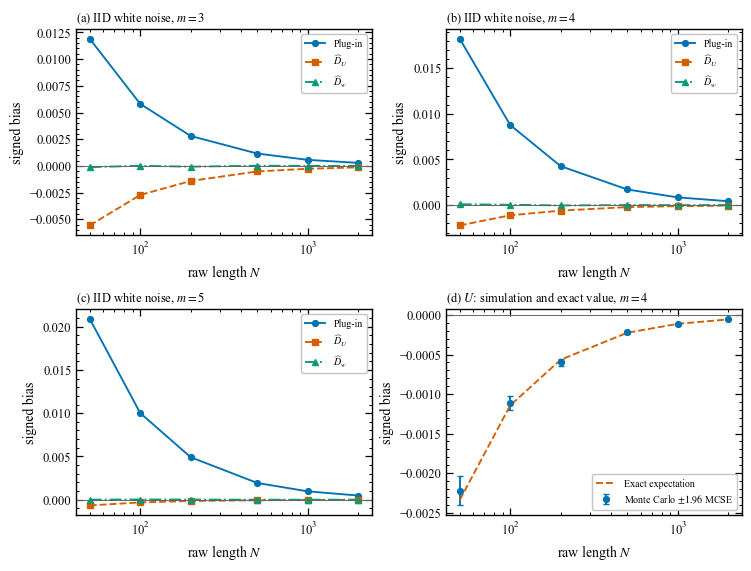

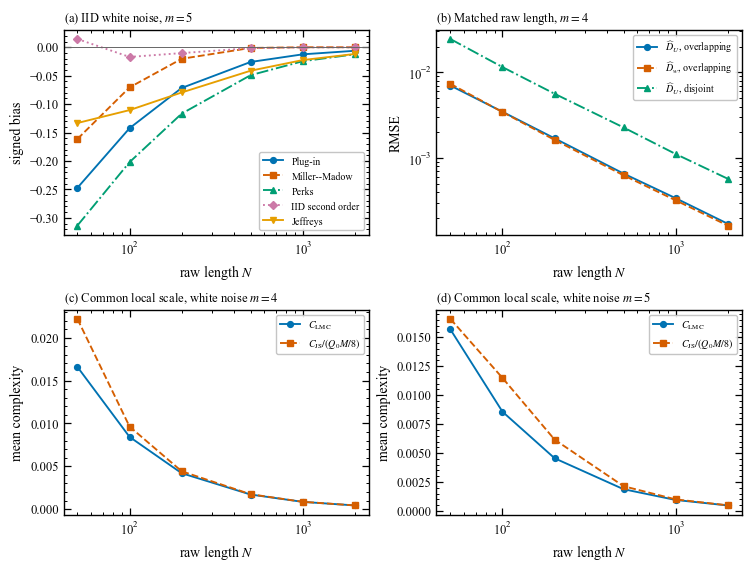

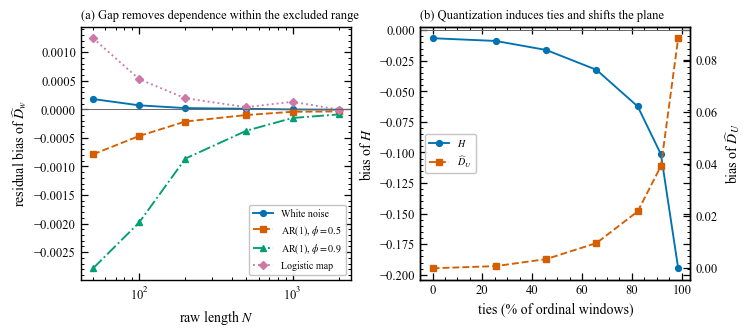

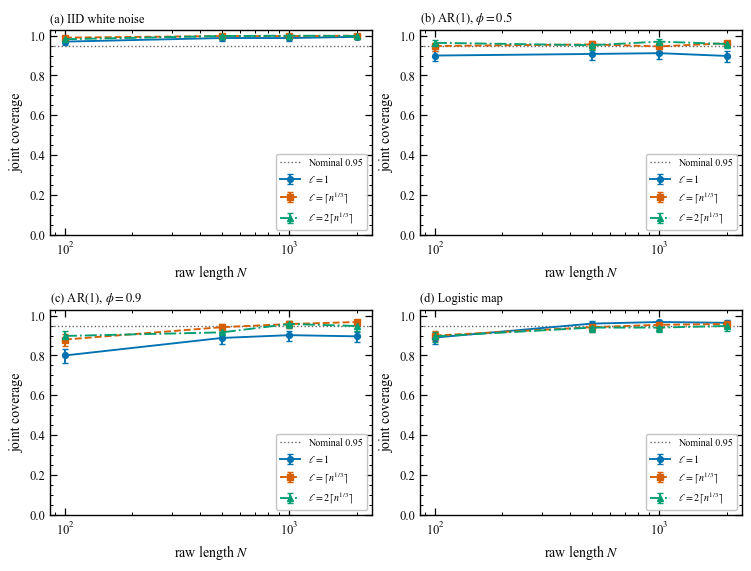

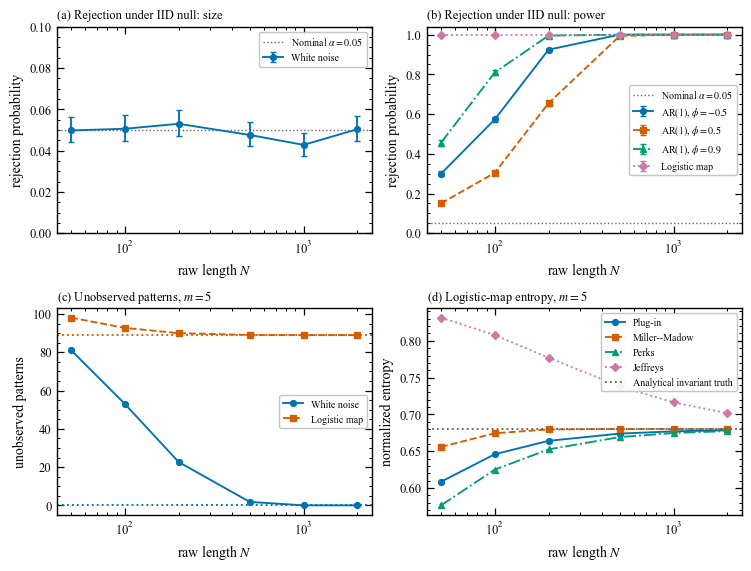

Figures 1–5 generated successfully.
PNG and vector PDF files saved in: /Users/rafaelferreira/1_Workspace_Ativo/Papers/Finite-sample bias in ordinal complexity–entropy plane/figures


In [17]:
# Figures 1–5: paper labels + SuperMongo-inspired colored layout

plt.rcParams.update({
    'font.family':'serif',
    'font.serif':['Times New Roman','Times','DejaVu Serif'],
    'mathtext.fontset':'stix',
    'font.size':9,
    'axes.labelsize':10,
    'axes.titlesize':9,
    'axes.linewidth':1.0,
    'xtick.direction':'in',
    'ytick.direction':'in',
    'xtick.top':True,
    'ytick.right':True,
    'xtick.major.size':5,
    'ytick.major.size':5,
    'xtick.minor.size':2.5,
    'ytick.minor.size':2.5,
    'xtick.major.width':0.9,
    'ytick.major.width':0.9,
    'xtick.minor.width':0.7,
    'ytick.minor.width':0.7,
    'legend.frameon':True,
    'legend.framealpha':0.90,
    'legend.facecolor':'white',
    'legend.edgecolor':'0.75',
    'legend.fontsize':7.2,
    'lines.linewidth':1.35,
    'lines.markersize':4.2,
    'pdf.fonttype':42,
    'ps.fonttype':42
})

colors=['#0072B2','#D55E00','#009E73','#CC79A7','#E69F00']
markers=['o','s','^','D','v']
styles=['-','--','-.',':','-']

def sel(df,**kw):
    z=df.copy()
    for k,v in kw.items():
        z=z[z[k]==v]
    return z.sort_values('N') if 'N' in z.columns else z

def sm(ax):
    ax.minorticks_on()
    ax.tick_params(which='both',direction='in',top=True,right=True)
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_linewidth(1.0)

def savefig(fig,name):
    fig.savefig(FIGDIR/f'{name}.png',dpi=400,bbox_inches='tight',pad_inches=0.05)
    fig.savefig(FIGDIR/f'{name}.pdf',bbox_inches='tight',pad_inches=0.05)
    plt.show()

# Figure 1
fig,axs=plt.subplots(2,2,figsize=(7.4,5.6),layout='constrained')

for ax,m,letter in zip(axs.flat[:3],[3,4,5],'abc'):
    for j,(metric,label) in enumerate([
        ('D_plugin','Plug-in'),
        ('D_U',r'$\widehat{D}_{U}$'),
        ('D_gap',r'$\widehat{D}_{w}$')]):
        r=sel(bias,model='white',m=m,metric=metric)
        ax.plot(r.N,r.bias,marker=markers[j],ls=styles[j],
                color=colors[j],label=label)
    ax.axhline(0,color='0.4',lw=.7)
    ax.set_xscale('log')
    ax.set_xlabel(r'raw length $N$')
    ax.set_ylabel(r'signed bias')
    ax.set_title(rf'({letter}) IID white noise, $m={m}$',loc='left')
    ax.legend(loc='best')
    sm(ax)

ax=axs[1,1]
r=sel(bias,model='white',m=4,metric='D_U')
ax.errorbar(r.N,r.bias,yerr=1.96*r.mcse,fmt='o',color=colors[0],
            capsize=2.5,label=r'Monte Carlo $\pm 1.96$ MCSE')
ax.plot(r.N,[iid_biases(4,int(n))['U'] for n in r.n],
        '--',color=colors[1],label='Exact expectation')
ax.axhline(0,color='0.4',lw=.7)
ax.set_xscale('log')
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel(r'signed bias')
ax.set_title(r'(d) $U$: simulation and exact value, $m=4$',loc='left')
ax.legend(loc='best')
sm(ax)

savefig(fig,'figure_1')

# Figure 2
fig,axs=plt.subplots(2,2,figsize=(7.4,5.6),layout='constrained')

ax=axs[0,0]
for j,(metric,label) in enumerate([
    ('H_plugin','Plug-in'),
    ('H_MM','Miller--Madow'),
    ('H_Perks','Perks'),
    ('H_iid_delta','IID second order'),
    ('H_Jeffreys','Jeffreys')]):
    r=sel(bias,model='white',m=5,metric=metric)
    ax.plot(r.N,r.bias,marker=markers[j],ls=styles[j],
            color=colors[j],label=label)
ax.axhline(0,color='0.4',lw=.7)
ax.set_xscale('log')
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel(r'signed bias')
ax.set_title(r'(a) IID white noise, $m=5$',loc='left')
ax.legend(loc='best',ncol=1)
sm(ax)

ax=axs[0,1]
for j,(model,metric,label) in enumerate([
    ('white','D_U',r'$\widehat{D}_{U}$, overlapping'),
    ('white','D_gap',r'$\widehat{D}_{w}$, overlapping'),
    ('disjoint','D_U',r'$\widehat{D}_{U}$, disjoint')]):
    r=sel(bias,model=model,m=4,metric=metric)
    ax.plot(r.N,r.rmse,marker=markers[j],ls=styles[j],
            color=colors[j],label=label)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel('RMSE')
ax.set_title(r'(b) Matched raw length, $m=4$',loc='left')
ax.legend(loc='best')
sm(ax)

for ax,m,letter in zip(axs[1],[4,5],'cd'):
    r=sel(bias,model='white',m=m,metric='C_LMC_plugin')
    ax.plot(r.N,r['mean'],'o-',color=colors[0],
            label=r'$C_{\rm LMC}$')
    r=sel(bias,model='white',m=m,metric='C_JS_plugin')
    scale=q0(factorial(m))*factorial(m)/8
    ax.plot(r.N,r['mean']/scale,'s--',color=colors[1],
            label=r'$C_{\rm JS}/(Q_0M/8)$')
    ax.set_xscale('log')
    ax.set_xlabel(r'raw length $N$')
    ax.set_ylabel('mean complexity')
    ax.set_title(rf'({letter}) Common local scale, white noise $m={m}$',loc='left')
    ax.legend(loc='best')
    sm(ax)

savefig(fig,'figure_2')

# Figure 3
fig,axs=plt.subplots(1,2,figsize=(7.4,3.25),layout='constrained')

ax=axs[0]
labs={
    'white':'White noise',
    'ar0.5':r'AR(1), $\phi=0.5$',
    'ar0.9':r'AR(1), $\phi=0.9$',
    'logistic':'Logistic map'
}
for j,model in enumerate(labs):
    ax.plot(Ns,[z['gap'] for z in gap_bias[model]],
            marker=markers[j],ls=styles[j],
            color=colors[j],label=labs[model])
ax.axhline(0,color='0.4',lw=.7)
ax.set_xscale('log')
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel(r'residual bias of $\widehat{D}_{w}$')
ax.set_title(r'(a) Gap removes dependence within the excluded range',loc='left')
ax.legend(loc='best')
sm(ax)

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(100*quantization.tie_fraction,quantization.H_bias,
           'o-',color=colors[0],label=r'$H$')[0]
l2=ax2.plot(100*quantization.tie_fraction,quantization.D_bias,
            's--',color=colors[1],label=r'$\widehat{D}_{U}$')[0]
ax.axhline(0,color='0.4',lw=.7)
ax.set_xlabel('ties (% of ordinal windows)')
ax.set_ylabel(r'bias of $H$',color='black')
ax2.set_ylabel(r'bias of $\widehat{D}_{U}$',color='black')
ax.tick_params(axis='y',colors='black')
ax2.tick_params(axis='y',colors='black')
ax.set_title(r'(b) Quantization induces ties and shifts the plane',loc='left')
ax.legend(handles=[l1,l2],
          labels=[r'$H$',r'$\widehat{D}_{U}$'],
          loc='center left')
sm(ax)
ax2.tick_params(which='both',direction='in',right=True)

savefig(fig,'figure_3')

# Figure 4
fig,axs=plt.subplots(2,2,figsize=(7.4,5.6),layout='constrained')

models=[
    ('white','IID white noise'),
    ('ar0.5',r'AR(1), $\phi=0.5$'),
    ('ar0.9',r'AR(1), $\phi=0.9$'),
    ('logistic','Logistic map')
]

for ax,(model,name),letter in zip(axs.flat,models,'abcd'):
    for j,(factor,label) in enumerate([
        (0,r'$\ell=1$'),
        (1,r'$\ell=\lceil n^{1/3}\rceil$'),
        (2,r'$\ell=2\lceil n^{1/3}\rceil$')]):
        r=sel(coverage,model=model,plane='JS',target='joint',factor=factor)
        y=r.coverage.to_numpy()
        ax.errorbar(r.N,y,
                    yerr=[y-r.ci_low.to_numpy(),
                          r.ci_high.to_numpy()-y],
                    marker=markers[j],ls=styles[j],
                    color=colors[j],capsize=2,label=label)
    ax.axhline(.95,color='0.4',ls=':',lw=1,label='Nominal 0.95')
    ax.set_xscale('log')
    ax.set_ylim(0,1.03)
    ax.set_xlabel(r'raw length $N$')
    ax.set_ylabel(r'joint coverage')
    ax.set_title(rf'({letter}) {name}',loc='left')
    ax.legend(loc='lower right')
    sm(ax)

savefig(fig,'figure_4')

# Figure 5
fig,axs=plt.subplots(2,2,figsize=(7.4,5.6),layout='constrained')

ax=axs[0,0]
r=sel(null_test,model='white')
y=r.rejection.to_numpy()
ax.errorbar(r.N,y,
            yerr=[y-r.ci_low.to_numpy(),
                  r.ci_high.to_numpy()-y],
            marker='o',ls='-',color=colors[0],
            capsize=2,label='White noise')
ax.axhline(.05,color='0.4',ls=':',lw=1,label=r'Nominal $\alpha=0.05$')
ax.set_xscale('log')
ax.set_ylim(0,.10)
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel('rejection probability')
ax.set_title('(a) Rejection under IID null: size',loc='left')
ax.legend(loc='best')
sm(ax)

ax=axs[0,1]
for j,model in enumerate(['ar-0.5','ar0.5','ar0.9','logistic']):
    labels={
        'ar-0.5':r'AR(1), $\phi=-0.5$',
        'ar0.5':r'AR(1), $\phi=0.5$',
        'ar0.9':r'AR(1), $\phi=0.9$',
        'logistic':'Logistic map'
    }
    r=sel(null_test,model=model)
    y=r.rejection.to_numpy()
    ax.errorbar(r.N,y,
                yerr=[y-r.ci_low.to_numpy(),
                      r.ci_high.to_numpy()-y],
                marker=markers[j],ls=styles[j],
                color=colors[j],capsize=2,label=labels[model])
ax.axhline(.05,color='0.4',ls=':',lw=1,label=r'Nominal $\alpha=0.05$')
ax.set_xscale('log')
ax.set_ylim(0,1.04)
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel('rejection probability')
ax.set_title('(b) Rejection under IID null: power',loc='left')
ax.legend(loc='best')
sm(ax)

ax=axs[1,0]
for j,(model,label) in enumerate([
    ('white','White noise'),
    ('logistic','Logistic map')]):
    r=sel(bias,model=model,m=5,metric='missing')
    ax.plot(r.N,r['mean'],marker=markers[j],ls=styles[j],
            color=colors[j],label=label)
    ax.axhline(float(r.truth.iloc[0]),
               color=colors[j],ls=':')
ax.set_xscale('log')
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel('unobserved patterns')
ax.set_title(r'(c) Unobserved patterns, $m=5$',loc='left')
ax.legend(loc='best')
sm(ax)

ax=axs[1,1]
for j,(metric,label) in enumerate([
    ('H_plugin','Plug-in'),
    ('H_MM','Miller--Madow'),
    ('H_Perks','Perks'),
    ('H_Jeffreys','Jeffreys')]):
    r=sel(bias,model='logistic',m=5,metric=metric)
    ax.plot(r.N,r['mean'],marker=markers[j],ls=styles[j],
            color=colors[j],label=label)
ax.axhline(float(r.truth.iloc[0]),
           color='0.4',ls=':',
           label='Analytical invariant truth')
ax.set_xscale('log')
ax.set_xlabel(r'raw length $N$')
ax.set_ylabel('normalized entropy')
ax.set_title(r'(d) Logistic-map entropy, $m=5$',loc='left')
ax.legend(loc='best')
sm(ax)

savefig(fig,'figure_5')

print('Figures 1–5 generated successfully.')
print('PNG and vector PDF files saved in:',FIGDIR.resolve())

## 9. Final line-by-line numerical audit against the manuscript
Analytical identities are marked **EXACT**. Simulation quantities are marked **MC CONSISTENT** only when the rerun agrees with the manuscript within an uncertainty-aware tolerance. Any discrepancy outside those criteria is marked **FAIL**.


In [11]:
# Final manuscript audit: EXACT / MC CONSISTENT / FAIL
# Targets below are the numerical values explicitly reported in the manuscript.
# Exact identities use tight numerical tolerances. Monte Carlo checks compare independent
# simulation realizations using their sampling uncertainty (or rounding-aware tolerances).

audit=[]

def exact_check(name, observed, target, atol):
    diff=abs(float(observed)-float(target))
    status='EXACT' if diff<=atol else 'FAIL'
    audit.append(dict(check=name,status=status,observed=float(observed),manuscript=float(target),
                      difference=diff,tolerance=float(atol),note='analytical/numerical identity'))
    print(f'{status:13s} {name}: observed={observed:.8g}; manuscript={target:.8g}; |diff|={diff:.3g}')

def mc_check(name, observed, target, tolerance, note='Monte Carlo / rounded manuscript value'):
    diff=abs(float(observed)-float(target))
    status='MC CONSISTENT' if diff<=tolerance else 'FAIL'
    audit.append(dict(check=name,status=status,observed=float(observed),manuscript=float(target),
                      difference=diff,tolerance=float(tolerance),note=note))
    print(f'{status:13s} {name}: observed={observed:.8g}; manuscript={target:.8g}; |diff|={diff:.3g}; tol={tolerance:.3g}')

# --- Table 1: exact overlap terms g(h) ---
TABLE1={3:[Fraction(-1,12),Fraction(-1,20)],
        4:[Fraction(-1,40),Fraction(-7,360),Fraction(-29,2520)],
        5:[Fraction(-1,180),Fraction(-1,210),Fraction(-37,10080),Fraction(-13,6048)]}
for m,targets in TABLE1.items():
    M=factorial(m)
    obs=[cp-Fraction(1,M) for cp in iid_collision_probabilities(m)]
    for h,(o,t) in enumerate(zip(obs,targets),1):
        exact_check(f'Table 1 g(h), m={m}, h={h}',float(o),float(t),1e-14)

# --- Exact reference probabilities / entropies ---
for m,target in [(3,.831445),(4,.739114),(5,.679849)]:
    p=logistic_probabilities(m)
    exact_check(f'Logistic analytical H, m={m}',float(functionals(p)[0]),target,6e-7)
    exact_check(f'Logistic allowed patterns, m={m}',int((p>0).sum()),{3:5,4:12,5:31}[m],0)
for phi,target in [(0.5,.00496),(0.9,.01605)]:
    exact_check(f'AR(1) analytical D, phi={phi}',float(functionals(ar_probabilities(4,phi))[1]),target,6e-6)

# --- Figure 1 / Sec. 3.1 ---
exact_check('Exact plug-in D bias, m=4 N=50',iid_biases(4,47)['plugin'],1.80982e-2,5e-8)
exact_check('Exact U bias, m=4 N=50',iid_biases(4,47)['U'],-2.34167e-3,5e-8)
r=sel(bias,model='white',m=4,N=50,metric='D_U').iloc[0]
# manuscript: -2.461e-3 +/- 0.093e-3 MCSE. Compare two independent MC means at 3 combined SE.
tol=3*np.sqrt(float(r.mcse)**2+(0.093e-3)**2)
mc_check('MC U bias, m=4 N=50',r.bias,-2.461e-3,tol,'3 x combined MCSE; manuscript MCSE=0.093e-3')
r=sel(bias,model='white',m=4,N=50,metric='D_gap').iloc[0]
tol=3*np.sqrt(float(r.mcse)**2+(1.02e-4)**2)
mc_check('MC gap bias, m=4 N=50',r.bias,-1.44e-4,tol,'3 x combined MCSE; manuscript MCSE=1.02e-4')

# --- Figure 2 / Sec. 3.2 ---
for metric,target,name in [('H_plugin',-0.2471,'Entropy plug-in bias, m=5 N=50'),
                           ('H_MM',-0.1611,'Miller--Madow bias, m=5 N=50')]:
    r=sel(bias,model='white',m=5,N=50,metric=metric).iloc[0]
    mc_check(name,r.bias,target,max(4*float(r.mcse),5e-4),'rounded manuscript value; 4 MCSE floor')
r=sel(bias,model='white',m=5,N=50,metric='H_plugin').iloc[0]
mc_check('Entropy plug-in RMSE, m=5 N=50',r.rmse,0.2477,max(4*float(r.mcse),8e-4),'manuscript Sec. 3.2')
r=sel(bias,model='white',m=5,N=50,metric='H_iid_delta').iloc[0]
# RMSE has its own sampling error; 0.002 absolute tolerance is conservative for R=5000 and manuscript rounding.
mc_check('IID second-order entropy RMSE, m=5 N=50',r.rmse,0.0230,0.002,'manuscript Sec. 3.2; rounded RMSE')

# --- Figure 3b / Sec. 3.4: tie fractions and H bias ---
TIE_TARGETS=[(25,-.009),(46,-.016),(66,-.032),(92,-.10)]
for pct,target in TIE_TARGETS:
    j=int(np.argmin(np.abs(100*quantization.tie_fraction.to_numpy()-pct)))
    rr=quantization.iloc[j]
    mc_check(f'Ties ~{pct}%: H bias',rr.H_bias,target,0.004,
             f'observed tie fraction={100*rr.tie_fraction:.2f}%')

# --- Figure 4 / Sec. 3.5: explicitly quoted JS joint coverage values ---
COV_TARGETS=[('ar0.5',100,.962),('ar0.9',100,.870),('logistic',100,.902),
             ('ar0.5',2000,.964),('ar0.9',2000,.940),('logistic',2000,.956)]
for model,N,target in COV_TARGETS:
    rr=sel(coverage,model=model,plane='JS',target='joint',factor=1,N=N).iloc[0]
    # Both manuscript and rerun use 500 outer replicates; 3 SE of difference of two binomial proportions.
    se=np.sqrt(target*(1-target)/R_BOOT + float(rr.coverage)*(1-float(rr.coverage))/R_BOOT)
    mc_check(f'Bootstrap JS joint coverage, {model}, N={N}, ell=ceil(n^1/3)',rr.coverage,target,max(3*se,0.012),
             '3 x SE for two independent 500-replicate coverage estimates')
# White-noise boundary statement: all reported coverages should lie in 0.976--1.000.
w=sel(coverage,model='white',plane='JS',target='joint')
white_min=float(w.coverage.min()); white_max=float(w.coverage.max())
status='MC CONSISTENT' if white_min>=0.95 and white_max<=1.0 else 'FAIL'
audit.append(dict(check='White-noise JS joint coverage range',status=status,observed=white_min,
                  manuscript=.976,difference=white_min-.976,tolerance=.026,
                  note=f'observed range={white_min:.3f}--{white_max:.3f}; manuscript states 0.976--1.000'))
print(f'{status:13s} White-noise JS joint coverage range: observed={white_min:.3f}--{white_max:.3f}; manuscript=0.976--1.000')

# --- Figure 5 / Sec. 3.6: size, power, structural zeros ---
rr=sel(null_test,model='white',N=50).iloc[0]
mc_check('Rank-test size, N=50',rr.rejection,.05,max(3*np.sqrt(.05*.95/R_TEST),.01),'target size alpha=0.05')
for model,target in [('ar-0.5',.285),('ar0.5',.160),('ar0.9',.455),('logistic',1.0)]:
    rr=sel(null_test,model=model,N=50).iloc[0]
    se=np.sqrt(max(target*(1-target),1e-12)/R_TEST + max(float(rr.rejection)*(1-float(rr.rejection)),1e-12)/R_TEST)
    mc_check(f'Rank-test power, {model}, N=50',rr.rejection,target,max(3*se,.002),
             '3 x SE for two independent R=5000 rejection estimates')
exact_check('Logistic structural zeros, m=5',factorial(5)-int((logistic_probabilities(5)>0).sum()),89,0)

verification=pd.DataFrame(audit)
display(verification)
print('\nSTATUS COUNTS')
print(verification.status.value_counts().to_string())
if (verification.status=='FAIL').any():
    print('\nFINAL AUDIT: FAIL -- inspect the rows above before archiving/submission.')
else:
    print('\nFINAL AUDIT: NO FAILURES -- analytical targets match and Monte Carlo targets are statistically consistent.')


EXACT         Table 1 g(h), m=3, h=1: observed=-0.083333333; manuscript=-0.083333333; |diff|=0
EXACT         Table 1 g(h), m=3, h=2: observed=-0.05; manuscript=-0.05; |diff|=0
EXACT         Table 1 g(h), m=4, h=1: observed=-0.025; manuscript=-0.025; |diff|=0
EXACT         Table 1 g(h), m=4, h=2: observed=-0.019444444; manuscript=-0.019444444; |diff|=0
EXACT         Table 1 g(h), m=4, h=3: observed=-0.011507937; manuscript=-0.011507937; |diff|=0
EXACT         Table 1 g(h), m=5, h=1: observed=-0.0055555556; manuscript=-0.0055555556; |diff|=0
EXACT         Table 1 g(h), m=5, h=2: observed=-0.0047619048; manuscript=-0.0047619048; |diff|=0
EXACT         Table 1 g(h), m=5, h=3: observed=-0.0036706349; manuscript=-0.0036706349; |diff|=0
EXACT         Table 1 g(h), m=5, h=4: observed=-0.0021494709; manuscript=-0.0021494709; |diff|=0
EXACT         Logistic analytical H, m=3: observed=0.83144548; manuscript=0.831445; |diff|=4.84e-07
EXACT         Logistic allowed patterns, m=3: observed=5; manus

,check,status,observed,manuscript,difference,tolerance,note
0,"Table 1 g(h), m=3, h=1",EXACT,-0.083333,-0.083333,0.000000e+00,1.000000e-14,analytical/numerical identity
1,"Table 1 g(h), m=3, h=2",EXACT,-0.050000,-0.050000,0.000000e+00,1.000000e-14,analytical/numerical identity
2,"Table 1 g(h), m=4, h=1",EXACT,-0.025000,-0.025000,0.000000e+00,1.000000e-14,analytical/numerical identity
3,"Table 1 g(h), m=4, h=2",EXACT,-0.019444,-0.019444,0.000000e+00,1.000000e-14,analytical/numerical identity
4,"Table 1 g(h), m=4, h=3",EXACT,-0.011508,-0.011508,0.000000e+00,1.000000e-14,analytical/numerical identity
5,"Table 1 g(h), m=5, h=1",EXACT,-0.005556,-0.005556,0.000000e+00,1.000000e-14,analytical/numerical identity
6,"Table 1 g(h), m=5, h=2",EXACT,-0.004762,-0.004762,0.000000e+00,1.000000e-14,analytical/numerical identity
7,"Table 1 g(h), m=5, h=3",EXACT,-0.003671,-0.003671,0.000000e+00,1.000000e-14,analytical/numerical identity
8,"Table 1 g(h), m=5, h=4",EXACT,-0.002149,-0.002149,0.000000e+00,1.000000e-14,analytical/numerical identity
9,"Logistic analytical H, m=3",EXACT,0.831445,0.831445,4.838586e-07,6.000000e-07,analytical/numerical identity



STATUS COUNTS
status
MC CONSISTENT    22
EXACT            20

FINAL AUDIT: NO FAILURES -- analytical targets match and Monte Carlo targets are statistically consistent.



## 10. Reproducibility note

Monte Carlo outputs are stochastic even with a fixed algorithm; changing NumPy/SciPy versions or the order in which a random-number generator is consumed can change the final Monte Carlo means while preserving the expected values within Monte Carlo uncertainty. The **exact analytical checks** should agree to numerical precision. Simulation checks are therefore evaluated with explicit tolerances rather than byte-for-byte equality.

For the public repository, archive the executed notebook together with the five generated PNG figures and the pinned software requirements used for the final run.
